In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
import tasep_models as tm
from tasep_models import *
from Bio import pairwise2
from Bio.pairwise2 import format_alignment  
import multiprocessing as mp
import os
mp.set_start_method('spawn', force=True)
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning:multiprocessing.resource_tracker'

=== CLEAN CORRELATION TEST ===
Signal length: 500 frames
Expected delay: 10 frames (10 seconds)
Using max_lag = 80 frames to avoid edge effects

=== CLEAN RESULTS ===
Expected peak: +10 seconds
Measured peak: 12.0 seconds
Error: 2.0 seconds
✅ CORRECT: Peak found at expected delay


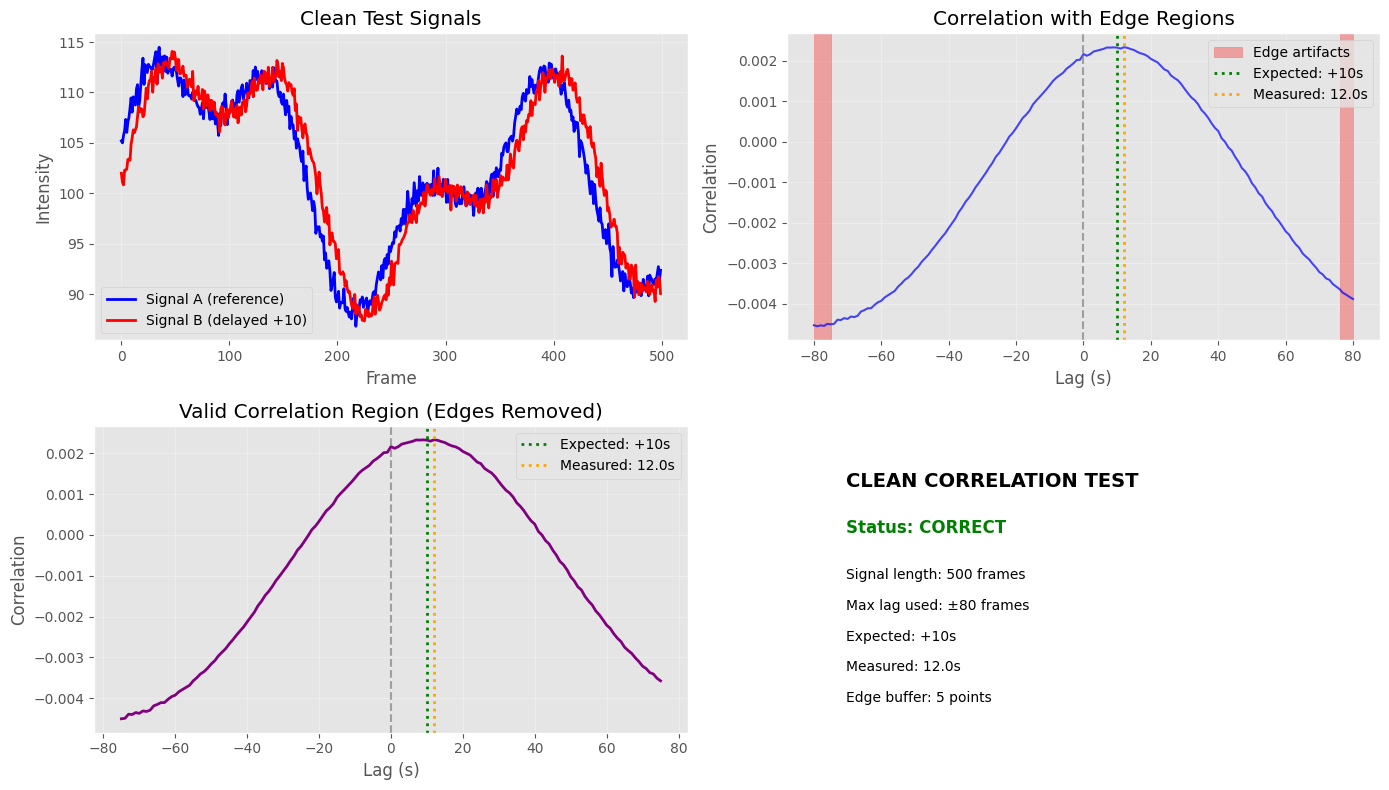

Exception ignored in: <function ResourceTracker.__del__ at 0x104b8f560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1078ff560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function Resour

In [ ]:

def test_correlation_with_edge_handling():
    """
    Test correlation with proper edge effect handling
    """
    # Parameters for synthetic signals
    N_frames = 500  # Longer signals for better correlation
    delay_frames = 10
    expected_delay_seconds = delay_frames * 1  # step_size_in_sec = 1
    n_trajectories = 50
    
    # Signal parameters
    base_mean = 100.0
    signal_amplitude = 10.0  # Larger amplitude for clearer signal
    noise_std = 5.0  # Lower noise
    
    print("=== CLEAN CORRELATION TEST ===")
    print(f"Signal length: {N_frames} frames")
    print(f"Expected delay: {delay_frames} frames ({expected_delay_seconds} seconds)")
    
    # Generate synthetic signals
    np.random.seed(42)
    time_base = np.arange(N_frames + delay_frames)
    
    # Create cleaner base signal with multiple features
    base_signal = base_mean + signal_amplitude * (
        np.sin(time_base * 0.02) +  # Main oscillation
        0.5 * np.sin(time_base * 0.05) +  # Secondary oscillation
        0.3 * np.sin(time_base * 0.01) +  # Slow trend
        0.2 * np.exp(-(time_base - 150)**2 / (2 * 40**2))  # Gaussian feature
    )
    
    # Smooth the signal
    base_signal = gaussian_filter1d(base_signal, sigma=2)
    
    # Create signals with proper delay
    synthetic_signal_A = np.zeros((n_trajectories, N_frames))
    synthetic_signal_B = np.zeros((n_trajectories, N_frames))
    
    for i in range(n_trajectories):
        # A is reference (takes later part)
        noise_A = np.random.normal(0, noise_std, N_frames)
        synthetic_signal_A[i, :] = base_signal[delay_frames:delay_frames + N_frames] + noise_A
        
        # B is delayed (takes earlier part)  
        noise_B = np.random.normal(0, noise_std, N_frames)
        synthetic_signal_B[i, :] = base_signal[:N_frames] + noise_B
    
    # Test correlation with LIMITED lag range to avoid edge effects
    max_lag_for_test = min(N_frames // 3, 80)  # Limit to 1/3 of signal length or 80 frames
    
    print(f"Using max_lag = {max_lag_for_test} frames to avoid edge effects")
    
    mean_corr_clean, std_corr_clean, lags_clean, corr_array_clean, _ = mi.Correlation(
        primary_data=synthetic_signal_A,
        secondary_data=synthetic_signal_B,
        max_lag=max_lag_for_test,  # Limit lag range
        nan_handling='forward_fill',
        shift_data=True,
        return_full=True,
        time_interval_between_frames_in_seconds=1,
        use_bootstrap=False,
        show_plot=False,
        start_lag=0,
        fit_type='linear',
        de_correlation_threshold=0.1,
        correct_baseline=True,
        use_linear_projection_for_lag_0=True,
        save_plots=False,
        use_global_mean=False,
        remove_outliers=True,
        MAD_THRESHOLD_FACTOR=6,
        plot_individual_trajectories=False,
        x_axes_min_max_list_values=[-max_lag_for_test, max_lag_for_test],
        plot_title="CLEAN CORRELATION TEST"
    ).run()
    
    # Find peak in valid region (exclude edges)
    edge_buffer = 5  # Exclude 5 points from each edge
    valid_indices = np.arange(edge_buffer, len(mean_corr_clean) - edge_buffer)
    valid_corr = mean_corr_clean[valid_indices]
    valid_lags = lags_clean[valid_indices]
    
    peak_idx_valid = np.argmax(valid_corr)
    peak_lag_clean = valid_lags[peak_idx_valid]
    
    print(f"\n=== CLEAN RESULTS ===")
    print(f"Expected peak: +{expected_delay_seconds} seconds")
    print(f"Measured peak: {peak_lag_clean:.1f} seconds")
    print(f"Error: {abs(peak_lag_clean - expected_delay_seconds):.1f} seconds")
    
    # Determine status
    if abs(peak_lag_clean - expected_delay_seconds) < 3:
        print("✅ CORRECT: Peak found at expected delay")
        status = "CORRECT"
    else:
        print("⚠️  Peak not at expected location")
        status = "UNCLEAR"
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Signal comparison
    time_frames = np.arange(N_frames)
    mean_A = np.mean(synthetic_signal_A, axis=0)
    mean_B = np.mean(synthetic_signal_B, axis=0)
    
    axes[0,0].plot(time_frames, mean_A, 'b-', label='Signal A (reference)', linewidth=2)
    axes[0,0].plot(time_frames, mean_B, 'r-', label=f'Signal B (delayed +{delay_frames})', linewidth=2)
    axes[0,0].set_title('Clean Test Signals')
    axes[0,0].set_xlabel('Frame')
    axes[0,0].set_ylabel('Intensity')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Full correlation with edge regions highlighted
    axes[0,1].plot(lags_clean, mean_corr_clean, 'b-', linewidth=1.5, alpha=0.7)
    axes[0,1].axvspan(lags_clean[0], lags_clean[edge_buffer], alpha=0.3, color='red', label='Edge artifacts')
    axes[0,1].axvspan(lags_clean[-edge_buffer], lags_clean[-1], alpha=0.3, color='red')
    axes[0,1].axvline(0, ls='--', color='gray', alpha=0.7)
    axes[0,1].axvline(expected_delay_seconds, ls=':', color='green', linewidth=2, label=f'Expected: +{expected_delay_seconds}s')
    axes[0,1].axvline(peak_lag_clean, ls=':', color='orange', linewidth=2, label=f'Measured: {peak_lag_clean:.1f}s')
    axes[0,1].set_title('Correlation with Edge Regions')
    axes[0,1].set_xlabel('Lag (s)')
    axes[0,1].set_ylabel('Correlation')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Valid region only
    axes[1,0].plot(valid_lags, valid_corr, 'purple', linewidth=2)
    axes[1,0].axvline(0, ls='--', color='gray', alpha=0.7)
    axes[1,0].axvline(expected_delay_seconds, ls=':', color='green', linewidth=2, label=f'Expected: +{expected_delay_seconds}s')
    axes[1,0].axvline(peak_lag_clean, ls=':', color='orange', linewidth=2, label=f'Measured: {peak_lag_clean:.1f}s')
    axes[1,0].set_title('Valid Correlation Region (Edges Removed)')
    axes[1,0].set_xlabel('Lag (s)')
    axes[1,0].set_ylabel('Correlation')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Summary
    axes[1,1].text(0.1, 0.8, f"CLEAN CORRELATION TEST", fontsize=14, fontweight='bold')
    axes[1,1].text(0.1, 0.65, f"Status: {status}", fontsize=12, 
                   color='green' if status == 'CORRECT' else 'orange', fontweight='bold')
    axes[1,1].text(0.1, 0.5, f"Signal length: {N_frames} frames", fontsize=10)
    axes[1,1].text(0.1, 0.4, f"Max lag used: ±{max_lag_for_test} frames", fontsize=10)
    axes[1,1].text(0.1, 0.3, f"Expected: +{expected_delay_seconds}s", fontsize=10)
    axes[1,1].text(0.1, 0.2, f"Measured: {peak_lag_clean:.1f}s", fontsize=10)
    axes[1,1].text(0.1, 0.1, f"Edge buffer: {edge_buffer} points", fontsize=10)
    axes[1,1].set_xlim(0, 1)
    axes[1,1].set_ylim(0, 1)
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return status, peak_lag_clean, expected_delay_seconds, mean_corr_clean, lags_clean

# Run the clean test
clean_status, clean_lag, clean_expected, clean_corr, clean_lags = test_correlation_with_edge_handling()

